In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Fase III: VISUALIZACIÓN DE LOS DATOS

In [2]:
df_hrlimpio=pd.read_csv("files/hr_clean.csv")

In [35]:
import importlib
import src.soporte_visualizaciones as sv

importlib.reload(sv)

vis = sv.Visualizaciones(df_hrlimpio)
import warnings
warnings.filterwarnings('ignore')

# FOCO: Económico

- **Objetivo general:** *Analizar si la deserción de empleados se relaciona con variables económicas asociadas a la estructura laboral,antiguedad y experiencia, y a la carga de trabajo.*

In [4]:
# ----- BLOQUE 1: Salario -----

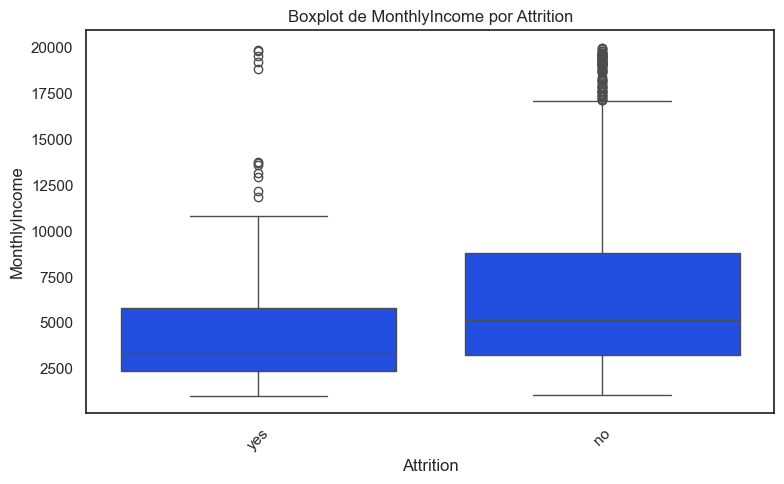

In [5]:
vis.boxplot(
    x="Attrition",
    y="MonthlyIncome"
)

In [6]:
df_hrlimpio["salary_cat"] = pd.qcut(df_hrlimpio["MonthlyIncome"], q=3, labels=["bajo", "medio", "alto"])

In [7]:
tabla_salario = pd.crosstab(df_hrlimpio["salary_cat"], df_hrlimpio["Attrition"], normalize="index")

tabla_salario["% rotacion"] = (tabla_salario["yes"] * 100).round(1).astype(str) + "%"

tabla_salario["Semaforo"] = tabla_salario["yes"].apply(semaforo)

tabla_salario[["yes", "% rotacion", "Semaforo"]]

NameError: name 'semaforo' is not defined

En esta gráfica se observa la comparación entre el salario mensual (MonthlyIncome) según la desercion (Attrition) de los empleados. Los empleados que abandonan la empresa (yes) presentan, en general, `salarios más bajos` que los que permanecen (no). Aun así, existen valores atípicos en ambos grupos, lo que indica que el salario no es el único factor que influye en la rotación.

In [8]:
# ----- BLOQUE 2: Estructura laboral -----

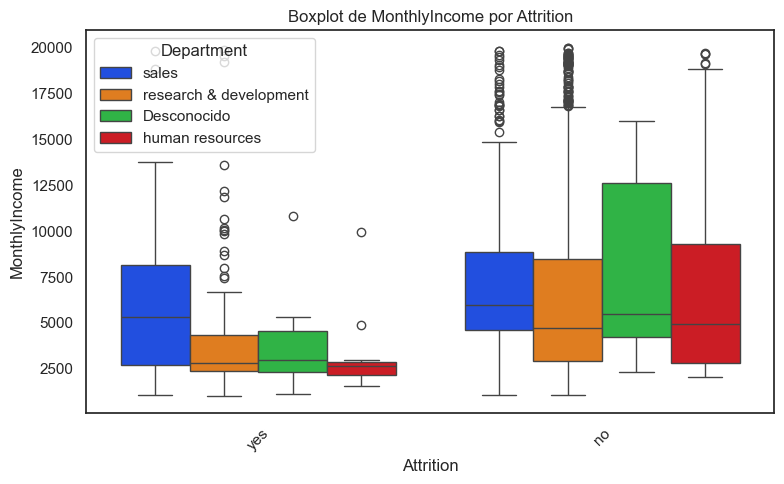

In [9]:
vis.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    hue="Department"
)

A nivel de outputs, este gráfico muestra que:

- Los empleados que no se van (no) tienen, en general, mayores salarios que los que sí se van (yes); que tienen `salarios más bajos, en todos los departamentos`.
- Research & Development y Sales concentran los salarios más altos y mayor variabilidad, especialmente entre los que permanecen.
- Human Resources presenta los salarios más bajos y una distribución más homogénea.
- Existen outliers en todos los grupos, lo que indica que hay empleados con salarios altos que también abandonan la empresa.

    - Se analizarán los valores nulos para identificar patrones, evaluar su impacto en el dataset y definir una estrategia de imputación o eliminación adecuada.

In [10]:
desconocidos=pd.crosstab(df_hrlimpio["Department"],df_hrlimpio["Attrition"],normalize="index")

In [11]:
desconocidos

Attrition,no,yes
Department,,
Desconocido,0.655172,0.344828
human resources,0.809524,0.190476
research & development,0.865815,0.134185
sales,0.797267,0.202733


El Departmento con etiqueta “desconocido” tiene la mayor tasa de rotación: 34% se va (yes), frente a:
- ~13% en R&D
- ~20% en Sales
- ~19% en HR

Lo que significa que los valores nulos no son aleatorios, están asociados a un comportamiento concreto como la posible falta de información o problemas en el registro de datos.

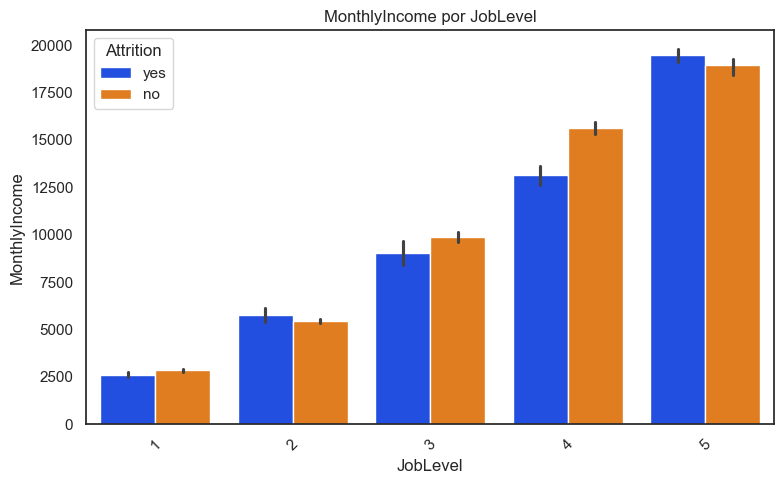

In [12]:
vis.barplot(
    x="JobLevel",
    y="MonthlyIncome",
    hue="Attrition"
)

In [13]:
tabla_sal_nivel = pd.crosstab([df_hrlimpio["JobLevel"], df_hrlimpio["salary_cat"]], df_hrlimpio["Attrition"], normalize="index")

tabla_sal_nivel["% rotacion"] = (tabla_sal_nivel["yes"] * 100).round(1).astype(str) + "%"

tabla_sal_nivel["Semaforo"] = tabla_sal_nivel["yes"].apply(semaforo)

tabla_sal_nivel[["yes", "% rotacion", "Semaforo"]]

NameError: name 'semaforo' is not defined

In [14]:
df_hrlimpio[df_hrlimpio["JobLevel"] == 3]["salary_cat"].value_counts() # Acabo de detectar que el nivel 3 es engañoso, ese 60% viene solo de 5 personas, por lo tanto, el nivel 3 no es tan problematico como parecia

salary_cat
alto     213
medio      5
bajo       0
Name: count, dtype: int64

A nivel de outputs, este gráfico muestra que:

- La rotación es significativamente mayor en los niveles más bajos, especialmente en el `nivel 1`, y disminuye a medida que aumenta el nivel del puesto. Esto confirma que los perfiles más junior son los que más abandonan la empresa (26%).

    - La alta rotación en niveles junior no solo se debe a una mayor propensión a abandonar la empresa, sino también a que en estos niveles `se concentran la mayor parte de la plantilla`. Esto amplifica el impacto de la rotación en perfiles de entrada.”

- La rotación no solo se concentra en la entrada (nivel 1), sino que reaparece en niveles intermedios (`nivel 3`), lo que sugiere problemas en la progresión profesional.

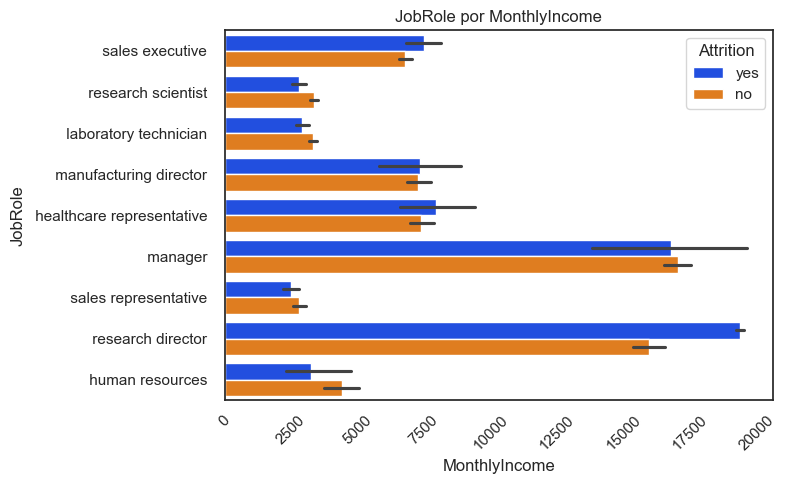

In [15]:
vis.barplot(
    x="MonthlyIncome",
    y="JobRole",
    hue="Attrition"
)

In [16]:
pd.crosstab(df_hrlimpio["JobRole"], df_hrlimpio["Attrition"], normalize="index")

Attrition,no,yes
JobRole,,
healthcare representative,0.931298,0.068702
human resources,0.769231,0.230769
laboratory technician,0.760618,0.239382
manager,0.950980,0.049020
manufacturing director,0.931034,0.068966
research director,0.975000,0.025000
research scientist,0.839041,0.160959
sales executive,0.825153,0.174847
sales representative,0.602410,0.397590


La gráfica muestra que el salario mensual `varía claramente según el puesto de trabajo`. Además, en varios puestos se observa que los empleados que abandonan la empresa presentan salarios medios inferiores a los de quienes permanecen, especialmente en puestos operativos y comerciales, `siendo crítica` en `Sales Representative` (casi 40%).

In [17]:
# ----- BLOQUE 3: Carga de trabajo -----

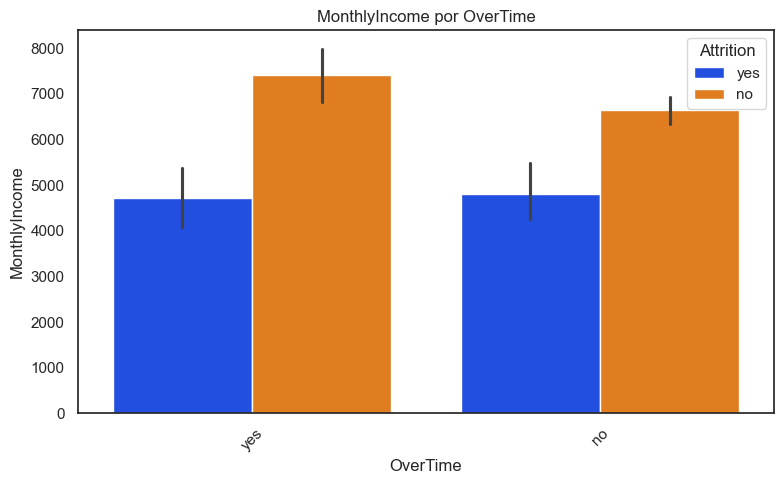

In [18]:
vis.barplot(
    x="OverTime",
    y="MonthlyIncome",
    hue="Attrition"
)

A nivel de outputs, este gráfico muestra que:
- Quienes se van (yes) cobran menos, con o sin horas extra.
- Los `empleados con menor salario que además realizan horas extra` presentan mayor tendencia a abandonar la empresa.

In [ ]:
# ----- BLOQUE 3: Antigüedad y experiencia -----

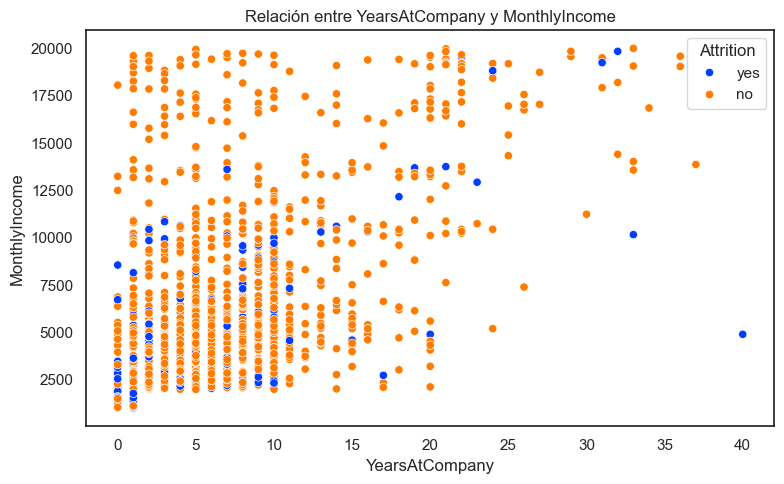

In [19]:
vis.scatterplot(
    x="YearsAtCompany",
    y="MonthlyIncome",
    hue="Attrition"
)

La mayor fuga de talento ocurre en los `primeros años del empleado en la empresa, donde coinciden menor salario, menor experiencia y peores condiciones`.


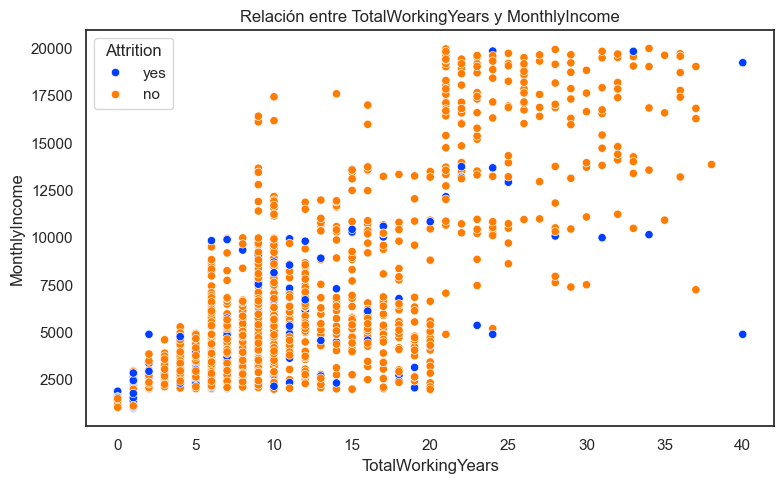

In [20]:
vis.scatterplot(
    x="TotalWorkingYears",
    y="MonthlyIncome",
    hue="Attrition"
)

La rotación se concentra en `empleados con menor experiencia y menor salario`, mientras que los perfiles más experimentados presentan mayor estabilidad.

# Resultados del enfoque: Económico = Patrones

1. El análisis muestra que la rotación no es homogénea, sino que se concentra principalmente en `perfiles junior`, donde alcanza alrededor del 26%, frente a menos del 10% en niveles senior.
    - El principal foco de rotación está en perfiles junior dentro de roles comerciales y operativos, `especialmente en Sales Representative`, , con casi un 40% de abandono, lo que indica un problema estructural en estas posiciones.
2. Desde el punto de vista salarial, observamos que los empleados que se marchan tienden a tener `salarios más bajos`; sin embargo, el salario por sí solo no explica completamente la rotación, ya que `también` existe abandono en `niveles altos`.

**Conclusión: La `deserción` está asociada a perfiles con `menor salario, menor experiencia y menor antigüedad`, pero `también` a `factores estructurales del puesto`, por lo que requiere estrategias de retención específicas.**

------------------------------------------------------------------------------------

C:\Users\Janira\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Janira\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Janira\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


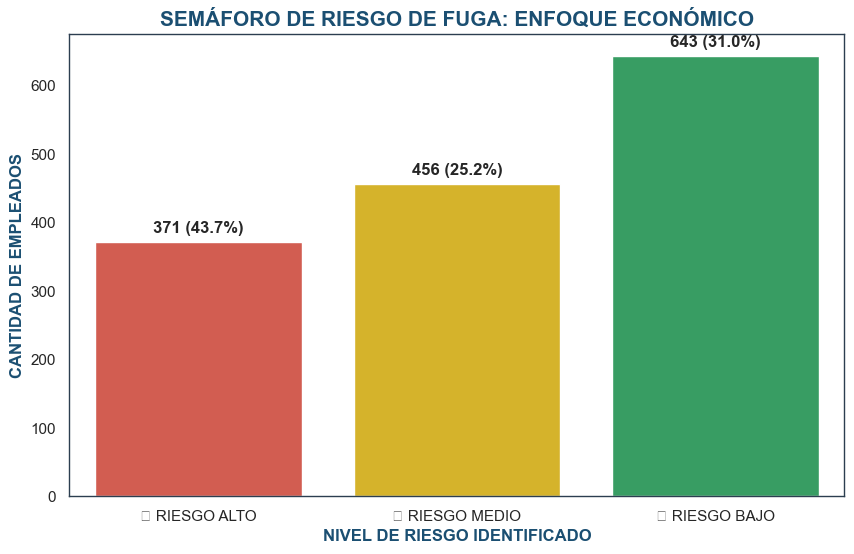

--- ANÁLISIS DE LA GRÁFICA 🚦 ---

🔴 RIESGO ALTO: 371 empleados (25.2%)
   POR QUÉ: Son empleados que acumulan varios factores de vulnerabilidad económica.
   Suelen combinar salario bajo, nivel de puesto bajo, poca antigüedad,
   poca experiencia total y, en muchos casos, horas extra.
   
🎯 PROPUESTA TRAS ANÁLISIS: intervención prioritaria con revisión salarial,
   planes de desarrollo profesional y medidas de reducción de sobrecarga laboral.


🟡 RIESGO MEDIO: 456 empleados (31.0%)
   POR QUÉ: Presentan algunos factores de riesgo, pero no de forma acumulada.
   Suelen tener condiciones intermedias de salario, experiencia o puesto,
   aunque ya muestran señales de alerta.
   
🎯 PROPUESTA TRAS ANÁLISIS: seguimiento periódico, revisión de progresión
   interna y acciones preventivas antes de que evolucionen a riesgo alto.


🟢 RIESGO BAJO: 643 empleados (43.7%)
   POR QUÉ: Son perfiles más consolidados y estables dentro de la organización.
   Suelen presentar mayor salario, mayor experienc

Attrition,no,yes
Semaforo_Riesgo,,
🔴 RIESGO ALTO,66.04,33.96
🟡 RIESGO MEDIO,85.75,14.25
🟢 RIESGO BAJO,92.85,7.15


In [21]:
# 1. MOTOR DE CÁLCULO UNIFICADO (Puntos por cada riesgo detectado)
def calcular_semaforo_final(row):
    puntos = 0
    motivos = []

    # --- ÁREA 1: COMPENSACIÓN (Salario e incentivos) ---
    if row['MonthlyIncome'] <= df_hrlimpio['MonthlyIncome'].quantile(0.25):
        puntos += 2
        motivos.append("Salario Bajo")
    if row['StockOptionLevel'] == 0:
        puntos += 1
        motivos.append("Sin Stock Options")

    # --- ÁREA 2: POSICIÓN PROFESIONAL (Nivel de puesto) ---
    if row['JobLevel'] == 1:
        puntos += 2
        motivos.append("JobLevel Bajo")
    elif row['JobLevel'] == 2:
        puntos += 1
        motivos.append("JobLevel Medio-Bajo")

    # --- ÁREA 3: TRAYECTORIA (Antigüedad y experiencia) ---
    if row['YearsAtCompany'] <= df_hrlimpio['YearsAtCompany'].quantile(0.25):
        puntos += 2
        motivos.append("Poca Antigüedad")
    elif row['YearsAtCompany'] <= df_hrlimpio['YearsAtCompany'].median():
        puntos += 1
        motivos.append("Antigüedad Media-Baja")

    if row['TotalWorkingYears'] <= df_hrlimpio['TotalWorkingYears'].quantile(0.25):
        puntos += 2
        motivos.append("Poca Experiencia Total")
    elif row['TotalWorkingYears'] <= df_hrlimpio['TotalWorkingYears'].median():
        puntos += 1
        motivos.append("Experiencia Media-Baja")

    # --- ÁREA 4: PRESIÓN LABORAL (Carga de trabajo) ---
    if row['OverTime'].lower() == 'yes':
        puntos += 2
        motivos.append("Horas Extra")

    # CLASIFICACIÓN FINAL
    if puntos >= 7:
        return '🔴 RIESGO ALTO', motivos
    if puntos >= 4:
        return '🟡 RIESGO MEDIO', motivos
    return '🟢 RIESGO BAJO', ["Estable"]


# Aplicamos la lógica
df_hrlimpio[['Semaforo_Riesgo', 'Detalles']] = df_hrlimpio.apply(
    lambda r: pd.Series(calcular_semaforo_final(r)), axis=1
)

# 2. CÁLCULO DE PORCENTAJES Y CANTIDADES
orden = ['🔴 RIESGO ALTO', '🟡 RIESGO MEDIO', '🟢 RIESGO BAJO']
resumen = df_hrlimpio['Semaforo_Riesgo'].value_counts().reindex(orden, fill_value=0)
total = len(df_hrlimpio)
pct = (resumen / total) * 100

# 3. VISUALIZACIÓN DEL SEMÁFORO
plt.figure(figsize=(10, 6))
colores_sem = {
    '🔴 RIESGO ALTO': '#E74C3C',
    '🟡 RIESGO MEDIO': '#F1C40F',
    '🟢 RIESGO BAJO': '#27AE60'
}

ax = sns.countplot(
    data=df_hrlimpio,
    x='Semaforo_Riesgo',
    palette=colores_sem,
    order=orden,
    hue='Semaforo_Riesgo',
    legend=False
)

# --- RECUADRO ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#2C3E50')
    spine.set_linewidth(1)

# Etiquetas de cantidad y % sobre las barras
for i, p in enumerate(ax.patches):
    categoria = orden[i]
    label = f"{int(p.get_height())} ({pct[categoria]:.1f}%)"
    ax.annotate(
        label,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontweight='bold'
    )

plt.title('SEMÁFORO DE RIESGO DE FUGA: ENFOQUE ECONÓMICO', fontsize=15, fontweight='bold', color='#1B4F72')
plt.ylabel('CANTIDAD DE EMPLEADOS', fontsize=12, fontweight='bold', color='#1B4F72')
plt.xlabel('NIVEL DE RIESGO IDENTIFICADO', fontsize=12, fontweight='bold', color='#1B4F72')
plt.show()


# 4. REPORTE EJECUTIVO "QUE HABLA"
print(f"--- ANÁLISIS DE LA GRÁFICA 🚦 ---")

for nivel in orden:
    cantidad = resumen.get(nivel, 0)
    porcentaje = (cantidad / total) * 100

    print(f"\n{nivel}: {cantidad} empleados ({porcentaje:.1f}%)")

    if nivel == '🔴 RIESGO ALTO':
        print("   POR QUÉ: Son empleados que acumulan varios factores de vulnerabilidad económica.")
        print("   Suelen combinar salario bajo, nivel de puesto bajo, poca antigüedad,")
        print("   poca experiencia total y, en muchos casos, horas extra.")
        print("   \n🎯 PROPUESTA TRAS ANÁLISIS: intervención prioritaria con revisión salarial,")
        print("   planes de desarrollo profesional y medidas de reducción de sobrecarga laboral.")
        print("\n" + "="*70)

    elif nivel == '🟡 RIESGO MEDIO':
        print("   POR QUÉ: Presentan algunos factores de riesgo, pero no de forma acumulada.")
        print("   Suelen tener condiciones intermedias de salario, experiencia o puesto,")
        print("   aunque ya muestran señales de alerta.")
        print("   \n🎯 PROPUESTA TRAS ANÁLISIS: seguimiento periódico, revisión de progresión")
        print("   interna y acciones preventivas antes de que evolucionen a riesgo alto.")
        print("\n" + "="*70)

    else:
        print("   POR QUÉ: Son perfiles más consolidados y estables dentro de la organización.")
        print("   Suelen presentar mayor salario, mayor experiencia, mejor nivel de puesto")
        print("   y menor acumulación de factores de riesgo.")
        print("   \n🎯 PROPUESTA TRAS ANÁLISIS: mantener condiciones competitivas y usar este")
        print("   grupo como referencia del perfil más estable de la plantilla.")

print("\n" + "="*70)


# 5. COMPROBACIÓN CON ATTRITION
tabla_attrition = round(
    pd.crosstab(df_hrlimpio['Semaforo_Riesgo'], df_hrlimpio['Attrition'], normalize='index') * 100,
    2
).reindex(orden)

display(tabla_attrition)

In [22]:
# -------------------------------------------

C:\Users\Janira\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Janira\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Janira\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


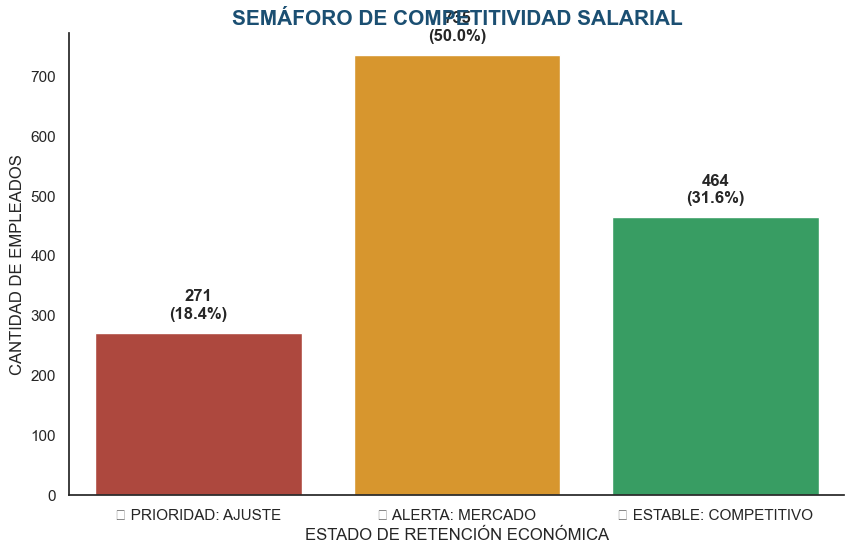

--- DIAGNÓSTICO FINANCIERO DE RETENCIÓN ---
• 🔴 EN RIESGO DE FUGA POR SUELDO: 271 empleados.
• 🟡 VULNERABLES AL MERCADO: 735 empleados.
• 🟢 COMPETITIVOS: 464 empleados.


In [23]:
# 1. MOTOR DE CÁLCULO ECONÓMICO (Basado en Mercado Interno)
def calcular_semaforo_economico(row):
    # Definimos la mediana de salario para su nivel de puesto como referencia
    mediana_nivel = df_hrlimpio[df_hrlimpio['JobLevel'] == row['JobLevel']]['MonthlyIncome'].median()

    puntos_riesgo = 0

    # Riesgo A: Salario por debajo de la mediana de su propio nivel
    if row['MonthlyIncome'] < mediana_nivel:
        puntos_riesgo += 2

    # Riesgo B: Nivel Junior (Nivel 1) - Son más volátiles
    if row['JobLevel'] == 1:
        puntos_riesgo += 2

    # Riesgo C: Estancamiento (Más de 3 años sin promoción)
    if row['YearsSinceLastPromotion'] >= 3:
        puntos_riesgo += 1

    # CLASIFICACIÓN DEL SEMÁFORO
    if puntos_riesgo >= 4:
        return '🔴 PRIORIDAD: AJUSTE', 'Bajo Salario / Perfil Junior'
    elif puntos_riesgo >= 2:
        return '🟡 ALERTA: MERCADO', 'Salario bajo mediana / Estancado'
    else:
        return '🟢 ESTABLE: COMPETITIVO', 'Sueldo acorde o superior'

# Aplicamos la lógica
df_hrlimpio[['Semaforo_Economico', 'Razon_Economica']] = df_hrlimpio.apply(
    lambda r: pd.Series(calcular_semaforo_economico(r)), axis=1
)

# 2. VISUALIZACIÓN DEL SEMÁFORO ECONÓMICO
plt.figure(figsize=(10, 6))
colores_econ = {
    '🔴 PRIORIDAD: AJUSTE': '#C0392B',
    '🟡 ALERTA: MERCADO': '#F39C12',
    '🟢 ESTABLE: COMPETITIVO': '#27AE60'
}

ax = sns.countplot(
    data=df_hrlimpio,
    x='Semaforo_Economico',
    palette=colores_econ,
    order=['🔴 PRIORIDAD: AJUSTE', '🟡 ALERTA: MERCADO', '🟢 ESTABLE: COMPETITIVO'],
    hue='Semaforo_Economico',
    legend=False
)

# Añadimos etiquetas de datos
total = len(df_hrlimpio)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(f'{int(p.get_height())}\n({percentage})',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 20),
                textcoords='offset points', fontweight='bold')

plt.title('SEMÁFORO DE COMPETITIVIDAD SALARIAL', fontsize=15, fontweight='bold', color='#1B4F72')
plt.ylabel('CANTIDAD DE EMPLEADOS')
plt.xlabel('ESTADO DE RETENCIÓN ECONÓMICA')
sns.despine()
plt.show()

# 3. REPORTE DE IMPACTO FINANCIERO
resumen_econ = df_hrlimpio['Semaforo_Economico'].value_counts()
print(f"--- DIAGNÓSTICO FINANCIERO DE RETENCIÓN ---")
print(f"• 🔴 EN RIESGO DE FUGA POR SUELDO: {resumen_econ.get('🔴 PRIORIDAD: AJUSTE', 0)} empleados.")
print(f"• 🟡 VULNERABLES AL MERCADO: {resumen_econ.get('🟡 ALERTA: MERCADO', 0)} empleados.")
print(f"• 🟢 COMPETITIVOS: {resumen_econ.get('🟢 ESTABLE: COMPETITIVO', 0)} empleados.")

ENFOQUE SATISFACION

In [25]:
from src.Clase_Bienestar import TalentSatisfactionAnalyzer

In [28]:
auditoria = TalentSatisfactionAnalyzer(df_hrlimpio)

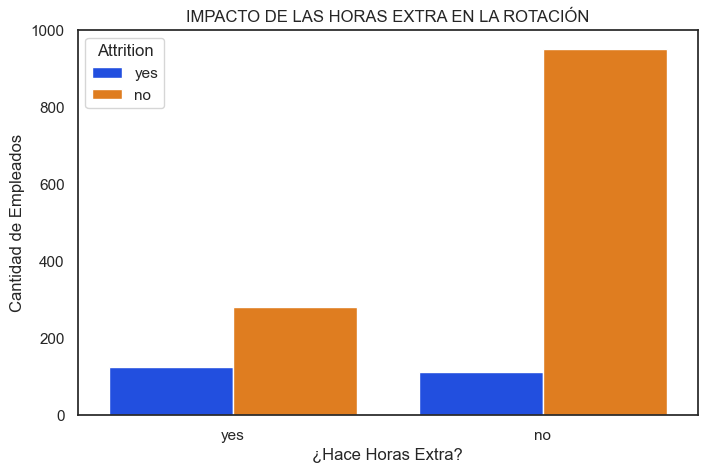

---REPORTE HORAS EXTRA VS ROTACIÓN ---
Personal con Horas Extra (no): 10.5% de fuga
Personal con Horas Extra (yes): 30.9% de fuga


In [29]:
auditoria.graficar_horas_extra()

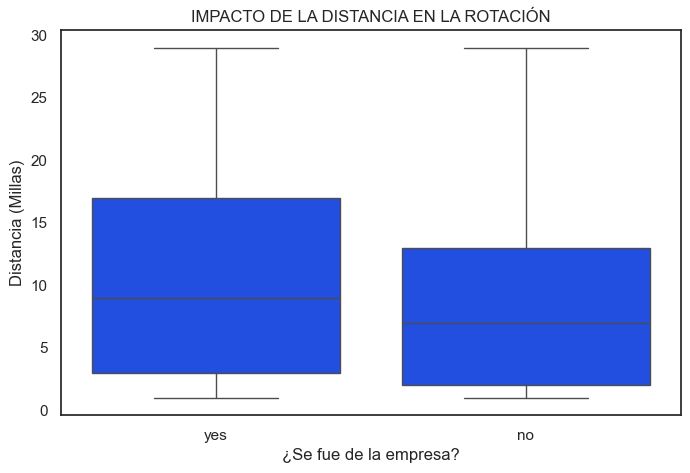

--- REPORTE DE DISTANCIA CASA-TRABAJO ---
Grupo que permanece: 7.0 millas
Grupo que renunció: 9.0 millas


In [33]:
auditoria.graficar_distancia()

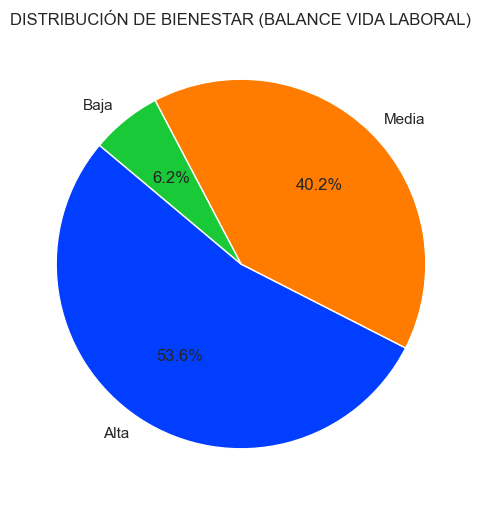

--- REPORTE DE BIENESTAR ---
Nivel Alta: 53.6% (788 empleados)
Nivel Media: 40.2% (591 empleados)
Nivel Baja: 6.2% (91 empleados)


In [32]:
auditoria.Balance_vida_laboral()

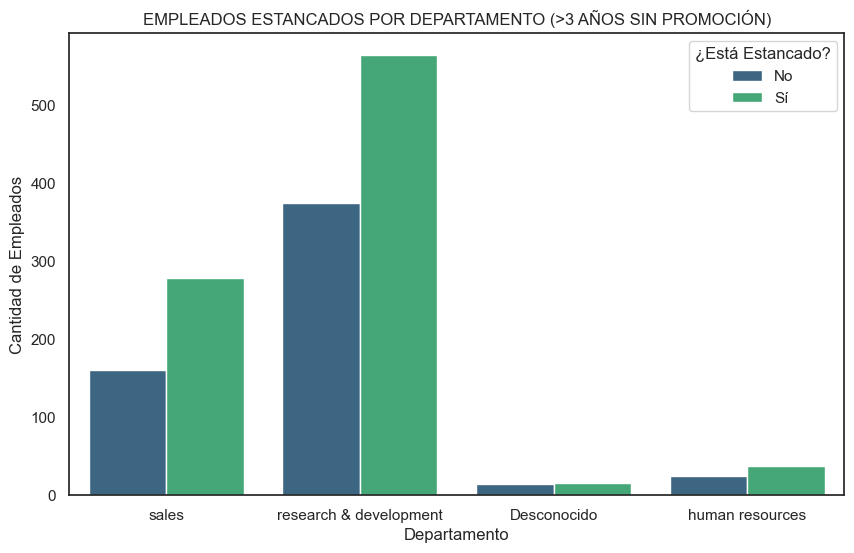

--- REPORTE DE ESTANCAMIENTO POR DEPARTAMENTO ---
DEPARTAMENTO              | ESTANCADOS         | ANTIGUEDAD   | EN EL ROL
DESCONOCIDO               |  15 de  29 (51.7%) |   5.0 años  |   2.0 años
HUMAN RESOURCES           |  38 de  63 (60.3%) |   5.0 años  |   2.0 años
RESEARCH & DEVELOPMENT    | 564 de 939 (60.1%) |   5.0 años  |   3.0 años
SALES                     | 279 de 439 (63.6%) |   6.0 años  |   3.0 años


In [31]:
auditoria.graficar_estancamiento_por_depto()

c:\Users\Janira\OneDrive\Documentos\adalab\proyectos\modulo 3\proyecto-da-promo-65-modulo-3-team-2\src\Clase_Bienestar.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, x="Nivel_Entorno", palette=["#E63946", "#FFB703", "#2A9D8F"])


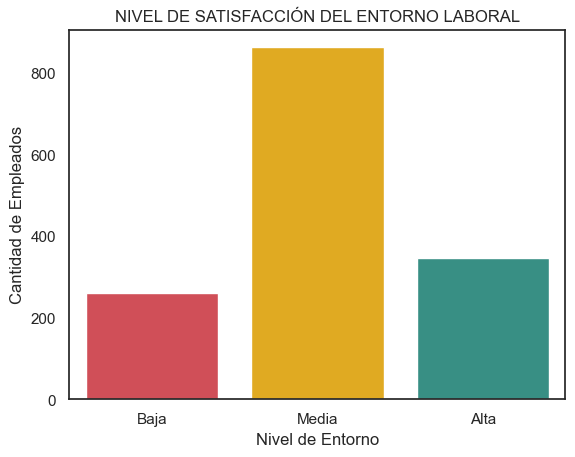

--- REPORTE DE SATISFACCIÓN DE ENTORNO ---
Nivel Baja: 261 empleados (Puntaje medio: 6.0)
Nivel Media: 862 empleados (Puntaje medio: 8.0)
Nivel Alta: 347 empleados (Puntaje medio: 10.0)


In [34]:
auditoria.analizar_satisfaccion_entorno()